Both plots saved with high resolution (600 DPI) for MS Word.


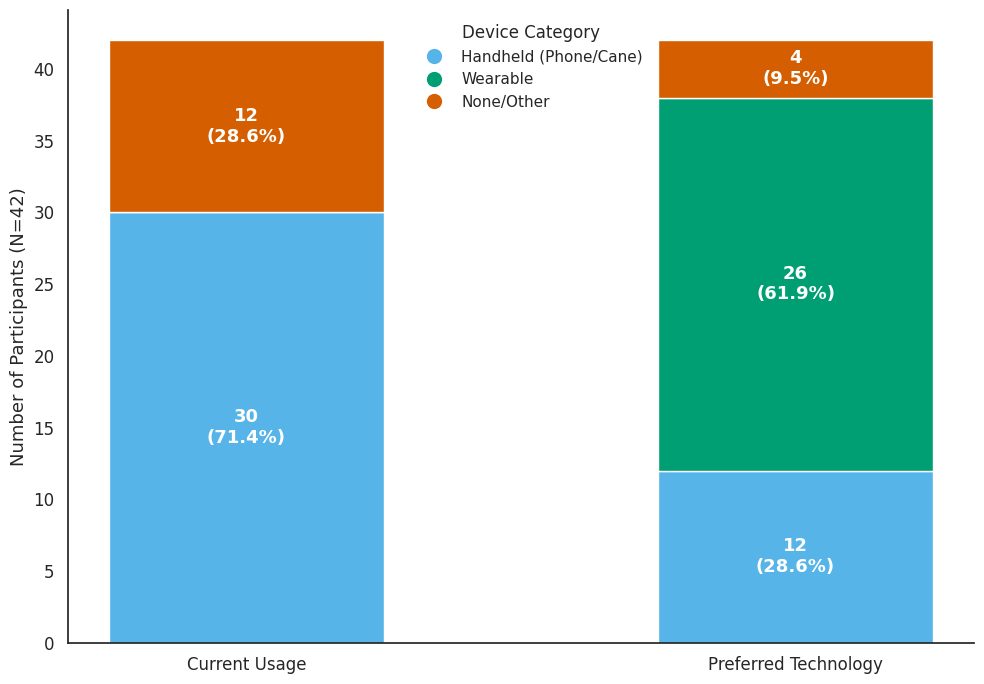

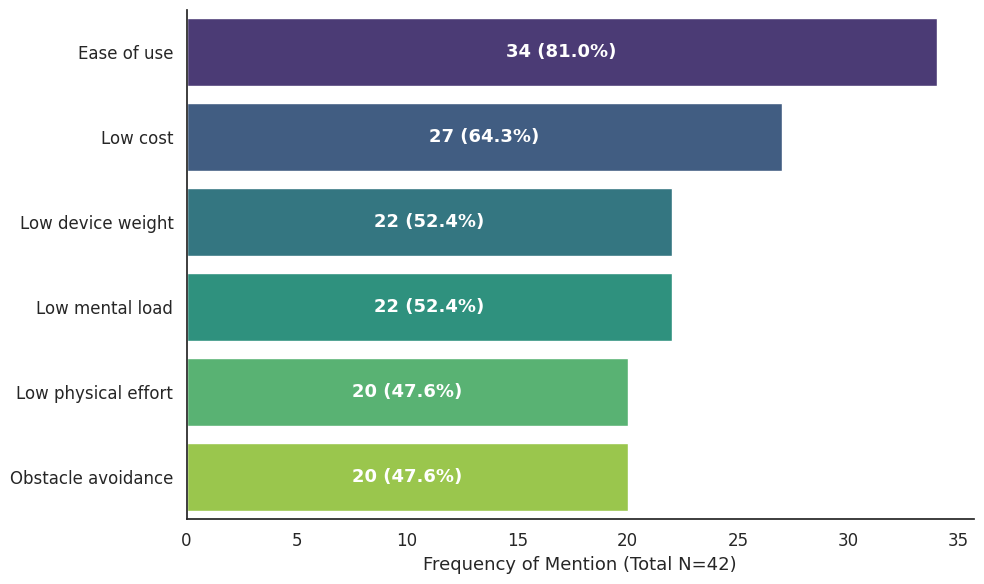

In [ ]:
#
# Used in paper
# accessible colors
# ensures 1-decimal point precision for percentages
# places all labels inside the bars
# uses circular legend markers
# optimized for maximum clarity in MS Word by using high resolution (600 DPI) and slightly larger standard fonts.
#
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# 1. Load the data
# Note: Ensure the filename matches your local file (e.g., .xlsx or .csv)
file_name = 'filled forms_Questions_Options.xlsx'
try:
    df = pd.read_excel(file_name)
except:
    # Fallback for the CSV version if running in the sandbox environment
    df = pd.read_csv('filled forms_Questions_Options.xlsx - Sheet1.csv')

# 2. Helper function to process multiple-choice columns
def clean_multi_choice(series):
    all_choices = []
    for val in series.dropna():
        cleaned = val.replace('[', '').replace(']', '').replace('"', '')
        choices = [c.strip() for c in cleaned.split(',')]
        all_choices.extend(choices)
    return pd.Series(all_choices).value_counts()

# Set global style for professional clarity
sns.set_style("white")
total_n = 42
# Accessible Color Palette
colors = ['#56B4E9', '#009E73', '#D55E00']

# --- PLOT 1: THE TECHNOLOGICAL SHIFT ---
fig1, ax1 = plt.subplots(figsize=(10, 7))

x_labels = ['Current Usage', 'Preferred Technology']
comparison_data = {
    'Handheld (Phone/Cane)': [30, 12],
    'Wearable': [0, 26],
    'None/Other': [12, 4]
}

bottom = [0, 0]
categories = list(comparison_data.keys())

for i, cat in enumerate(categories):
    ax1.bar(x_labels, comparison_data[cat], bottom=bottom, label=cat, color=colors[i], width=0.5)
    for j, val in enumerate(comparison_data[cat]):
        if val > 2: # Only show text if there is enough space in the bar segment
            percent = (val / total_n) * 100
            ax1.text(j, bottom[j] + val/2, f'{val}\n({percent:.1f}%)',
                     ha='center', va='center', color='white', fontweight='bold', fontsize=13)
    bottom = [b + v for b, v in zip(bottom, comparison_data[cat])]

# Remove "other lines" (top and right spines + grid) for a clean look
sns.despine(ax=ax1)
ax1.grid(False)

# Formatting labels for clarity in MS Word
ax1.set_ylabel('Number of Participants (N=42)', fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Create custom legend handles using disks (circles)
legend_elements = [Line2D([0], [0], marker='o', color='w', label=cat,
                          markerfacecolor=colors[i], markersize=12)
                   for i, cat in enumerate(categories)]

ax1.legend(handles=legend_elements, title="Device Category",
           loc='upper right', bbox_to_anchor=(0.65, 1), frameon=False,
           title_fontsize=12, fontsize=11)

plt.tight_layout()
# Saved with 600 DPI for high-quality printing/insertion in Word
plt.savefig('tech_shift_clean.png', dpi=600, bbox_inches='tight')


# --- PLOT 2: USER PRIORITIES ---
fig2, ax2 = plt.subplots(figsize=(10, 6))

q16_col = 'Q16. Which of the following characteristics are most important to you when using assistive technology for navigation? (Multiple options possible) (required)'
top_chars = clean_multi_choice(df[q16_col]).head(6)

# Horizontal bar plot
sns.barplot(x=top_chars.values, y=top_chars.index, palette='viridis', ax=ax2, hue=top_chars.index, legend=False)

# Labels placed INSIDE the bars with 1-decimal percentage
for i, v in enumerate(top_chars.values):
    percent = (v / total_n) * 100
    ax2.text(v / 2, i, f'{v} ({percent:.1f}%)',
             color='white', ha='center', va='center', fontweight='bold', fontsize=13)

# Clean axes
sns.despine(ax=ax2)
ax2.set_xlabel(f'Frequency of Mention (Total N={total_n})', fontsize=13)
ax2.set_ylabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
# Saved with 600 DPI for high-quality printing/insertion in Word
plt.savefig('user_priorities_on_bars.png', dpi=600, bbox_inches='tight')

print("Both plots saved with high resolution (600 DPI) for MS Word.")
plt.show()

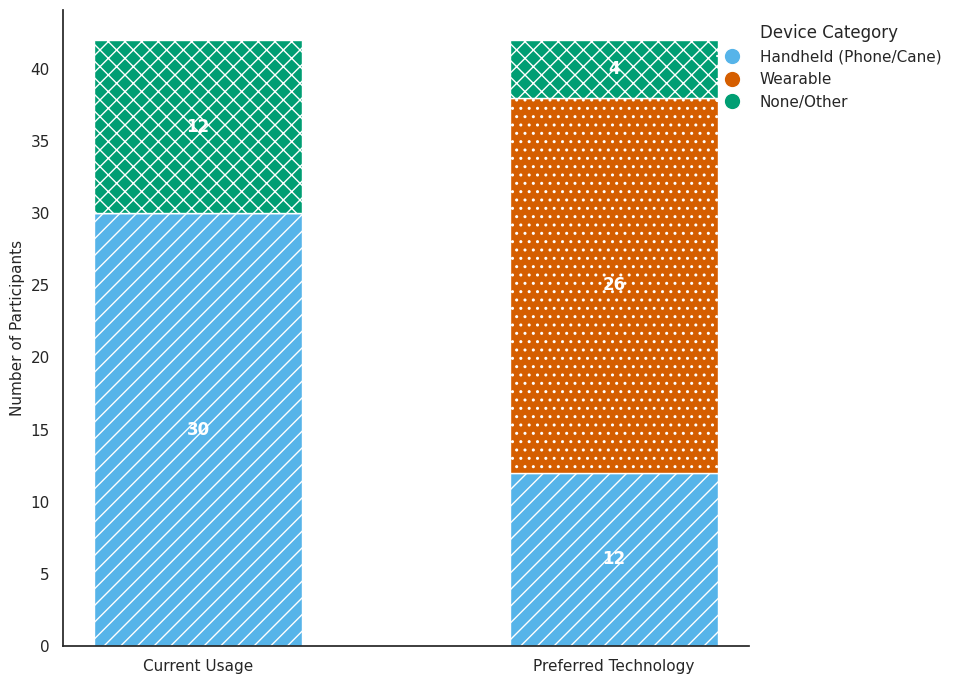

In [ ]:
#
# Accessible colors
#
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# 1. Load the data
file_name = 'filled forms_Questions_Options.xlsx'
df = pd.read_excel(file_name)

# 2. Helper function to process multiple-choice columns
def clean_multi_choice(series):
    all_choices = []
    for val in series.dropna():
        cleaned = val.replace('[', '').replace(']', '').replace('"', '')
        choices = [c.strip() for c in cleaned.split(',')]
        all_choices.extend(choices)
    return pd.Series(all_choices).value_counts()

# Set global style to 'white' (removes grid by default)
sns.set_style("white")

# 1. Accessible Color Palette (Okabe-Ito inspired)
# Blue, Vermillion (Orange-Red), and Bluish Green
accessible_colors = ['#56B4E9', '#D55E00', '#009E73']
hatches = ['//', '..', 'xx'] # Patterns for non-color distinction

# --- PLOT 1: THE TECHNOLOGICAL SHIFT ---
fig1, ax1 = plt.subplots(figsize=(10, 7))
sns.set_style("white")

x_labels = ['Current Usage', 'Preferred Technology']
comparison_data = {
    'Handheld (Phone/Cane)': [30, 12],
    'Wearable': [0, 26],
    'None/Other': [12, 4]
}

bottom = [0, 0]
categories = list(comparison_data.keys())

for i, cat in enumerate(categories):
    # Added 'hatch' for texture-based accessibility
    ax1.bar(x_labels, comparison_data[cat], bottom=bottom,
            label=cat, color=accessible_colors[i],
            hatch=hatches[i], edgecolor='white', width=0.5)

    for j, val in enumerate(comparison_data[cat]):
        if val > 0:
            ax1.text(j, bottom[j] + val/2, f'{val}',
                     ha='center', va='center', color='white', fontweight='bold')
    bottom = [b + v for b, v in zip(bottom, comparison_data[cat])]

# Custom Legend with Disks
legend_elements = [Line2D([0], [0], marker='o', color='w', label=cat,
                          markerfacecolor=accessible_colors[i], markersize=12)
                   for i, cat in enumerate(categories)]

ax1.legend(handles=legend_elements, title="Device Category",
           loc='upper right', bbox_to_anchor=(1.3, 1), frameon=False)

sns.despine(ax=ax1)
# ax1.set_title('The Strategic Shift: From Handheld to Wearable', fontsize=14, fontweight='bold', pad=20)
ax1.set_ylabel('Number of Participants', fontsize=11)

plt.tight_layout()
plt.show()

# # --- PLOT 2: USER PRIORITIES ---
# fig2, ax2 = plt.subplots(figsize=(10, 6))

# # Extract top characteristics
# q16_col = 'Q16. Which of the following characteristics are most important to you when using assistive technology for navigation? (Multiple options possible) (required)'
# top_chars = clean_multi_choice(df[q16_col]).head(6)

# # Create horizontal bar chart
# sns.barplot(x=top_chars.values, y=top_chars.index, palette='viridis', ax=ax2)

# # Add count labels
# for i, v in enumerate(top_chars.values):
#     ax2.text(v + 0.5, i, str(v), color='black', va='center', fontweight='bold')

# # Remove "other lines"
# sns.despine(ax=ax2)
# ax2.grid(False)

# ax2.set_title('User Priorities: Key Requirements for Ideal DAT', fontsize=14, fontweight='bold', pad=20)
# ax2.set_xlabel('Frequency of Mention', fontsize=11)
# ax2.set_ylabel('')

# plt.tight_layout()
# plt.savefig('user_priorities_clean.png', dpi=300, bbox_inches='tight')
# print("Saved: user_priorities_clean.png")
# plt.show()